In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r".\dm2_25_26_dataset\cmi_internet.csv")
df.shape

(8460, 82)

In [3]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [4]:
for col in df.columns:
    print(col)

id
Basic_Demos-Enroll_Season
Basic_Demos-Age
Basic_Demos-Sex
CGAS-Season
CGAS-CGAS_Score
Physical-Season
Physical-BMI
Physical-Height
Physical-Weight
Physical-Waist_Circumference
Physical-Diastolic_BP
Physical-HeartRate
Physical-Systolic_BP
Fitness_Endurance-Season
Fitness_Endurance-Max_Stage
Fitness_Endurance-Time_Mins
Fitness_Endurance-Time_Sec
FGC-Season
FGC-FGC_CU
FGC-FGC_CU_Zone
FGC-FGC_GSND
FGC-FGC_GSND_Zone
FGC-FGC_GSD
FGC-FGC_GSD_Zone
FGC-FGC_PU
FGC-FGC_PU_Zone
FGC-FGC_SRL
FGC-FGC_SRL_Zone
FGC-FGC_SRR
FGC-FGC_SRR_Zone
FGC-FGC_TL
FGC-FGC_TL_Zone
BIA-Season
BIA-BIA_Activity_Level_num
BIA-BIA_BMC
BIA-BIA_BMI
BIA-BIA_BMR
BIA-BIA_DEE
BIA-BIA_ECW
BIA-BIA_FFM
BIA-BIA_FFMI
BIA-BIA_FMI
BIA-BIA_Fat
BIA-BIA_Frame_num
BIA-BIA_ICW
BIA-BIA_LDM
BIA-BIA_LST
BIA-BIA_SMM
BIA-BIA_TBW
PAQ_A-Season
PAQ_A-PAQ_A_Total
PAQ_C-Season
PAQ_C-PAQ_C_Total
PCIAT-Season
PCIAT-PCIAT_01
PCIAT-PCIAT_02
PCIAT-PCIAT_03
PCIAT-PCIAT_04
PCIAT-PCIAT_05
PCIAT-PCIAT_06
PCIAT-PCIAT_07
PCIAT-PCIAT_08
PCIAT-PCIAT_09
PCIAT-

In [5]:
df["sii"].notnull().sum()

np.int64(8460)

In [6]:
df.drop(["id"], inplace=True, axis=1)
df.shape

(8460, 81)

In [7]:
columns_with_missing_values = []
for col in df.columns:
    if df[col].isna().sum() > 0:
        columns_with_missing_values.append(col)

columns_with_missing_values.__len__()

77

C:\Users\nicco\AppData\Local\Temp\ipykernel_21260\1040239997.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


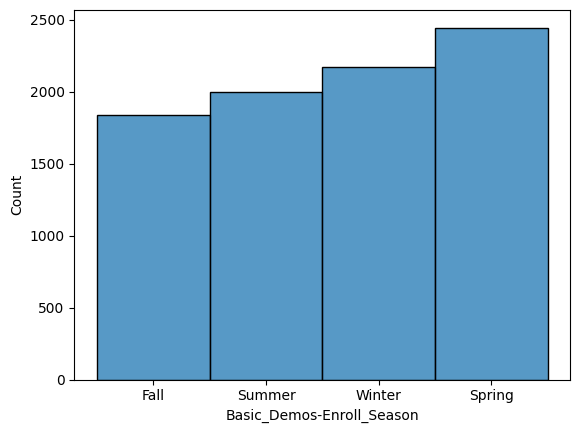

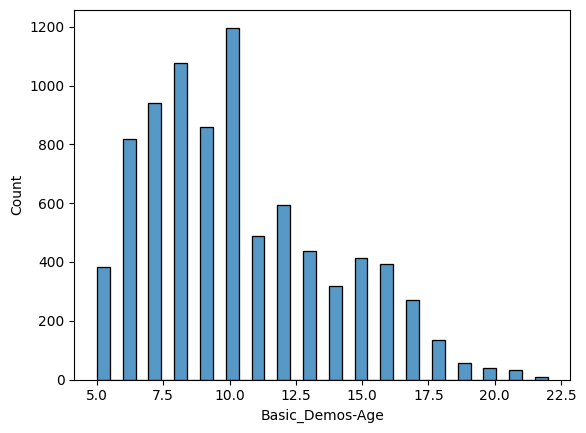

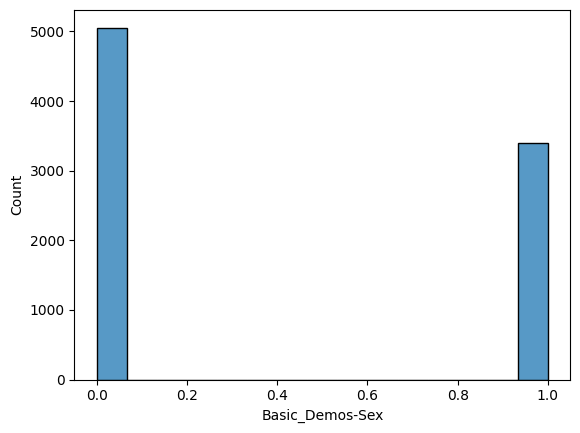

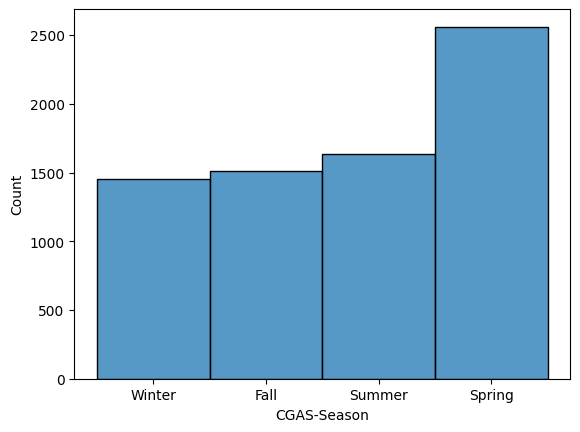

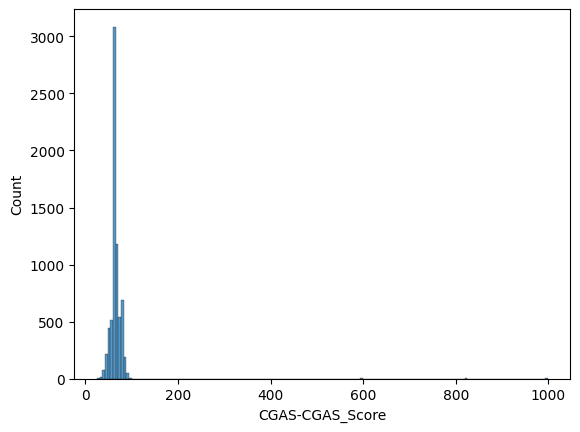

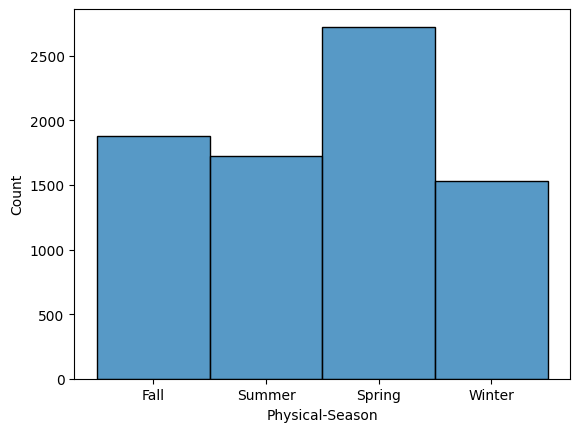

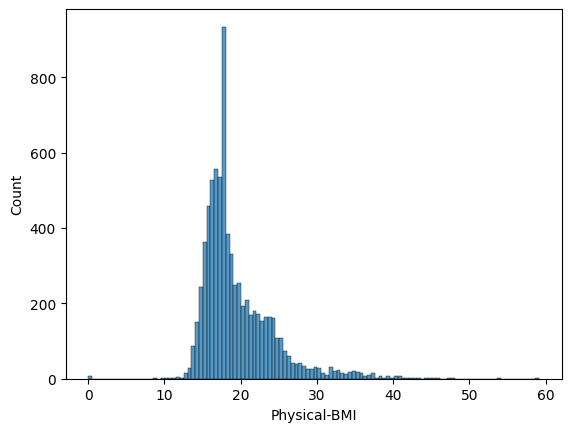

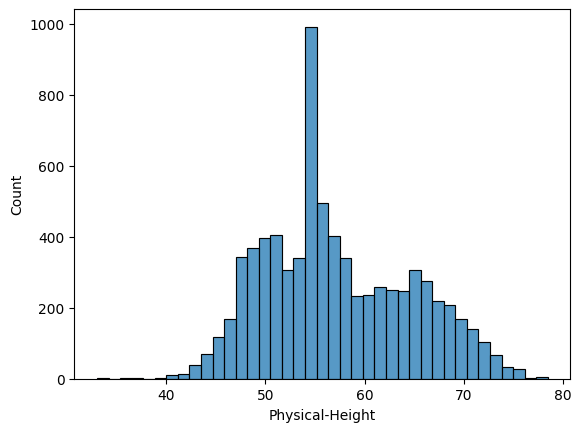

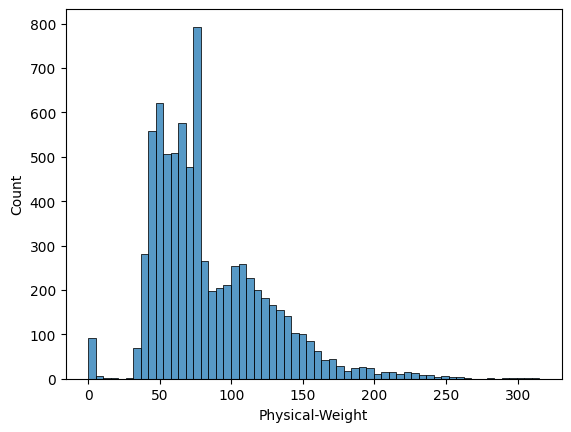

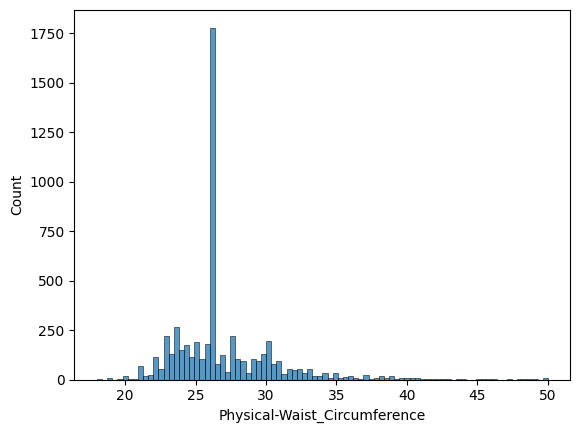

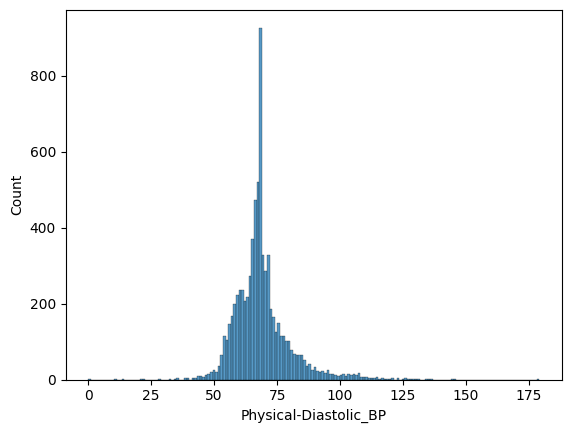

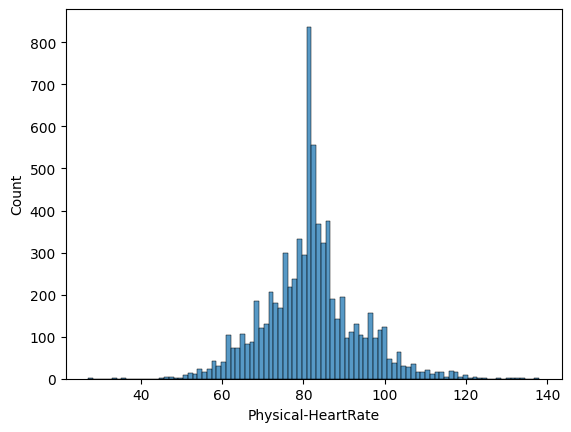

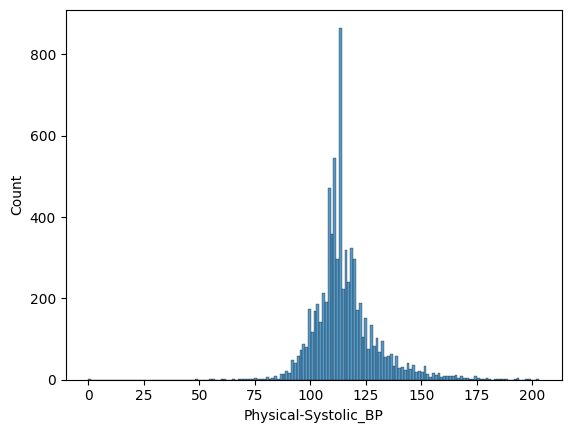

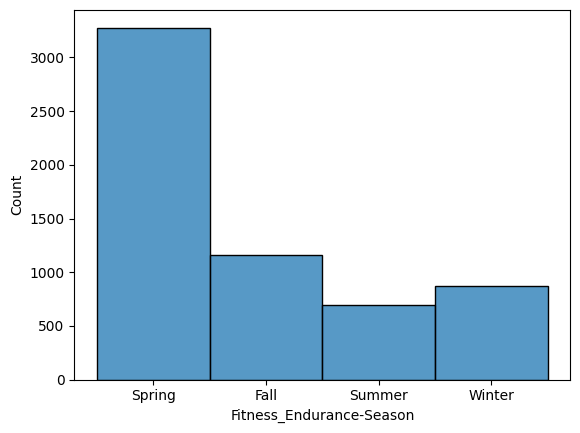

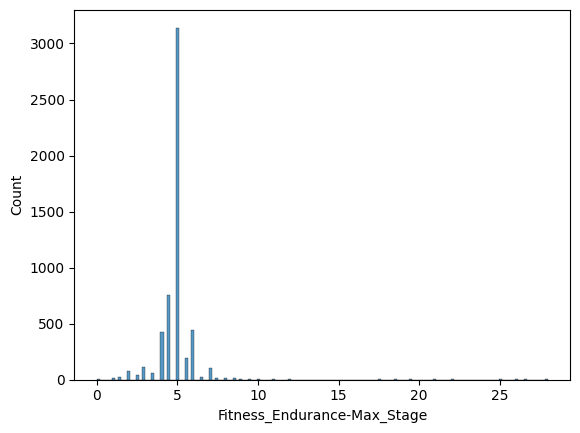

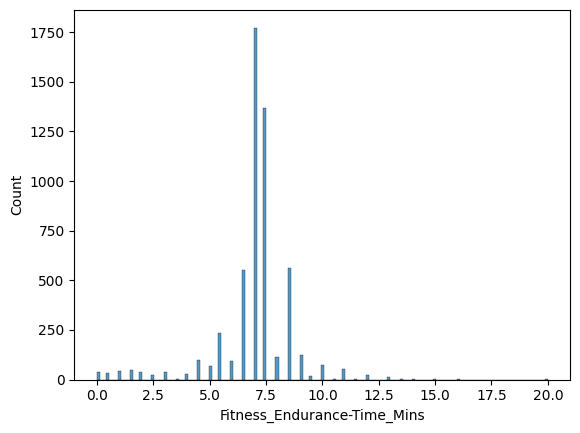

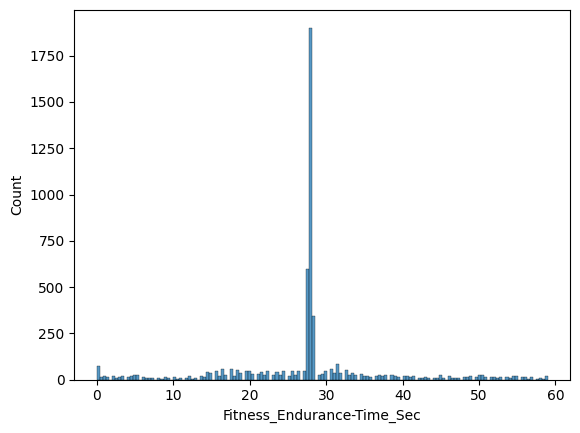

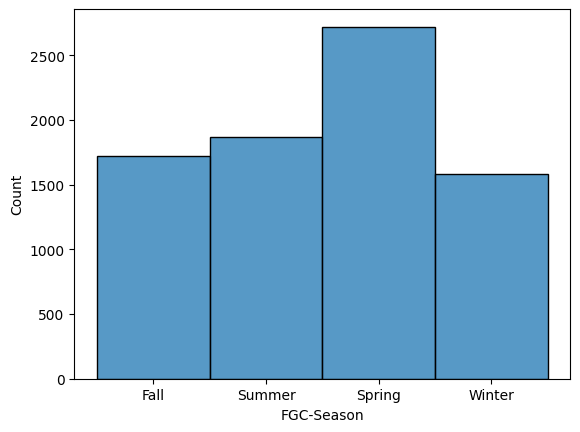

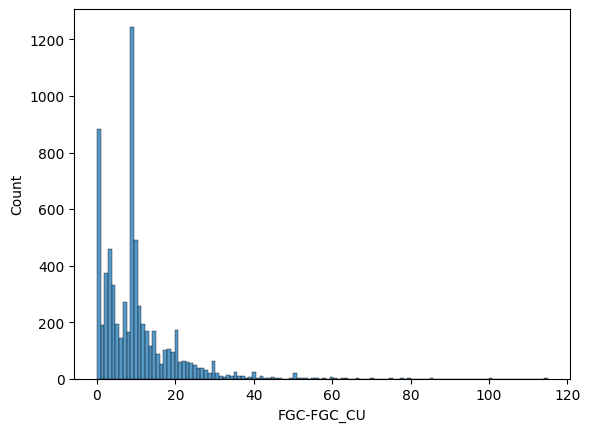

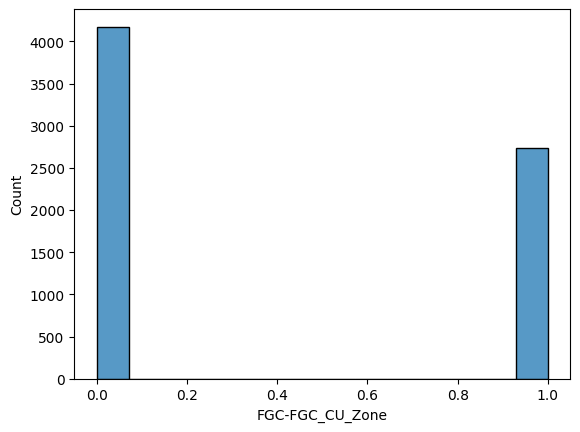

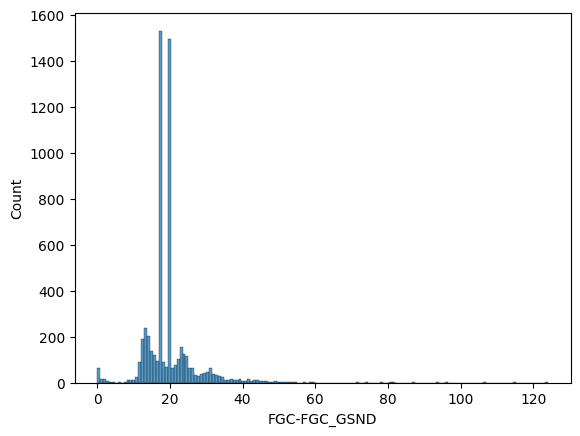

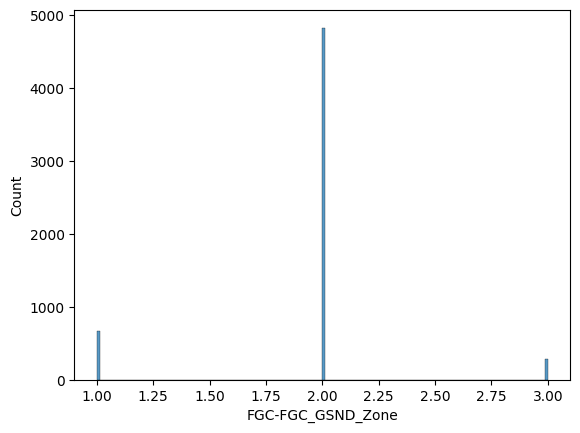

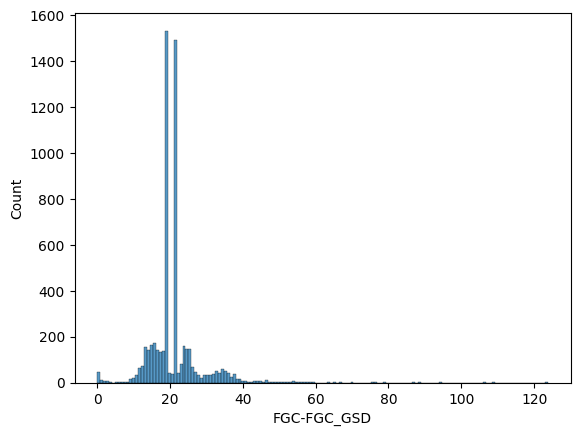

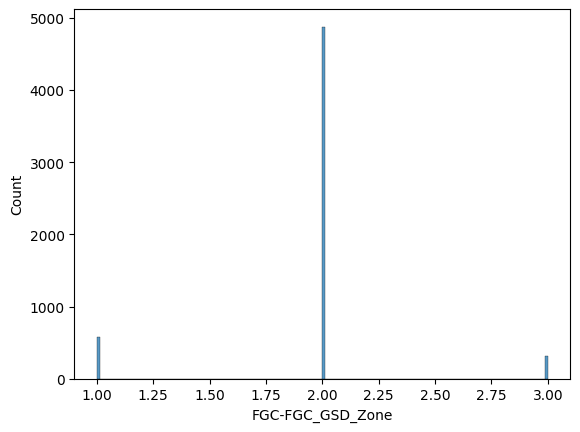

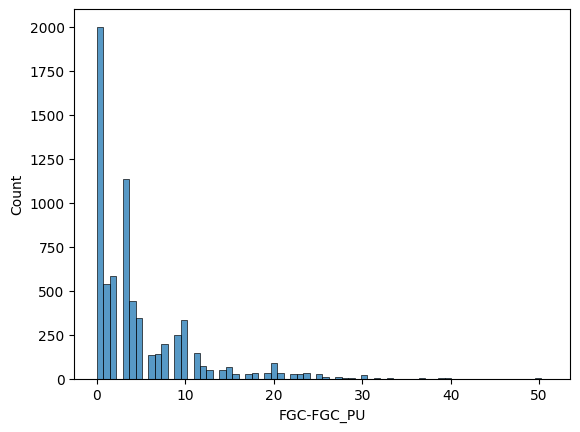

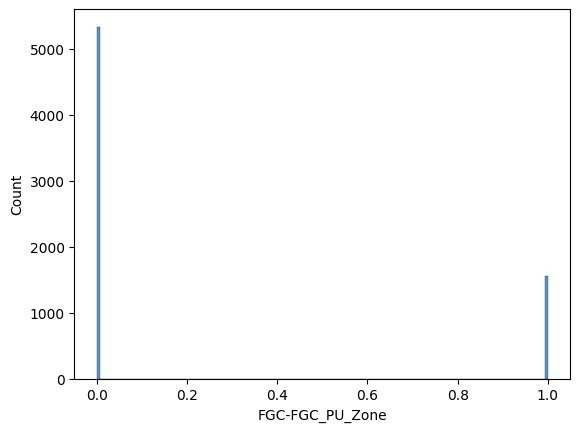

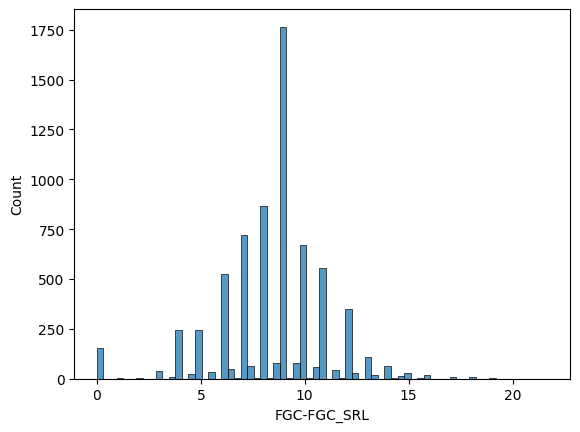

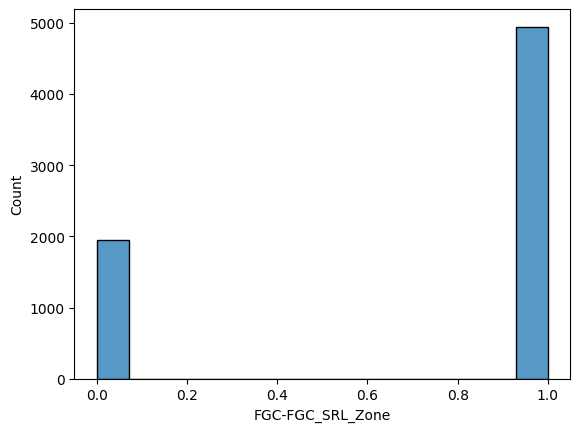

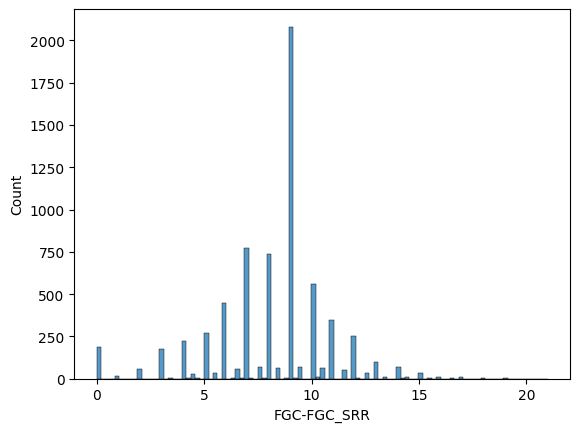

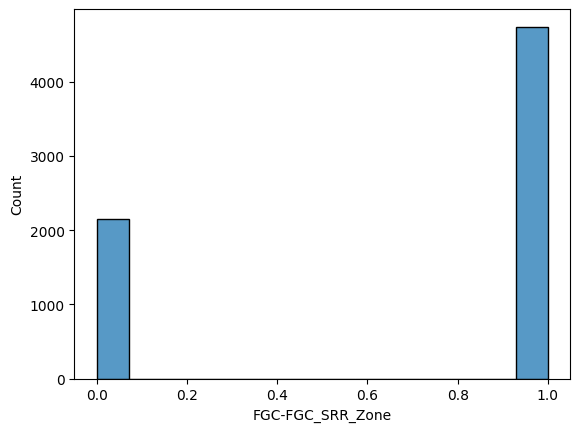

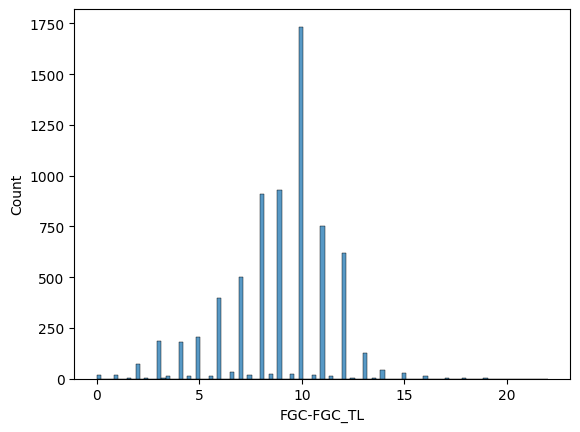

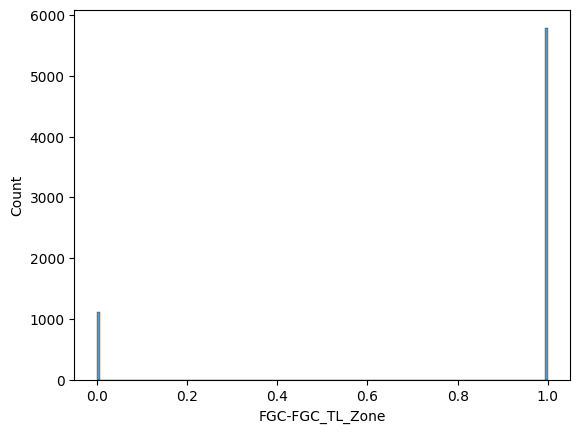

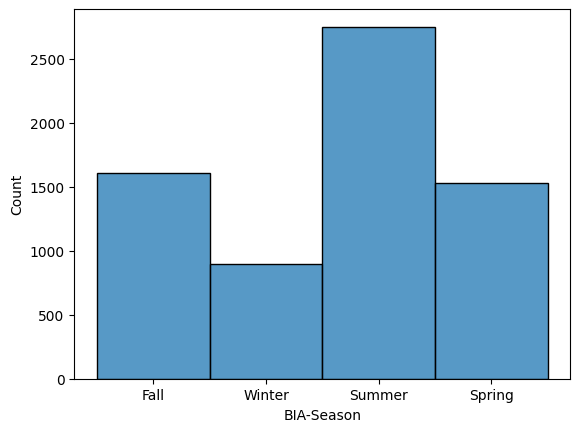

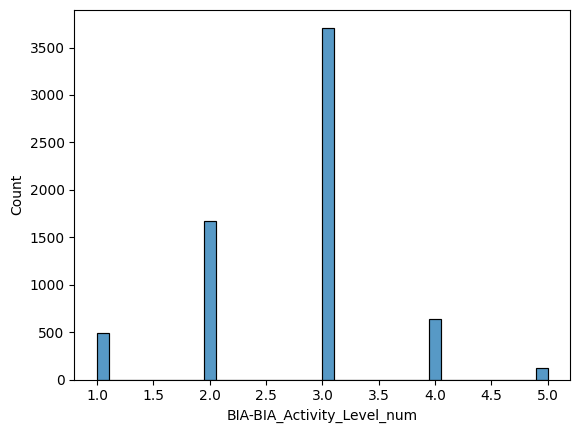

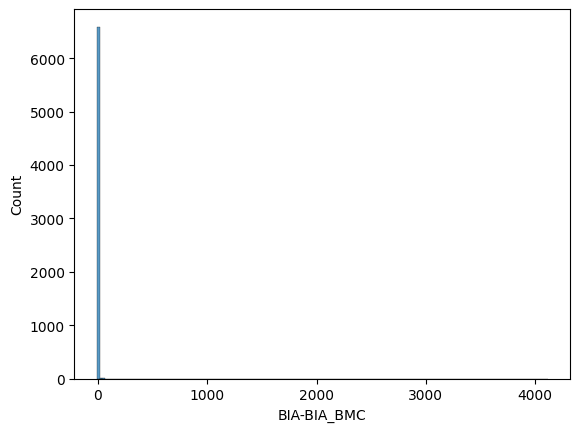

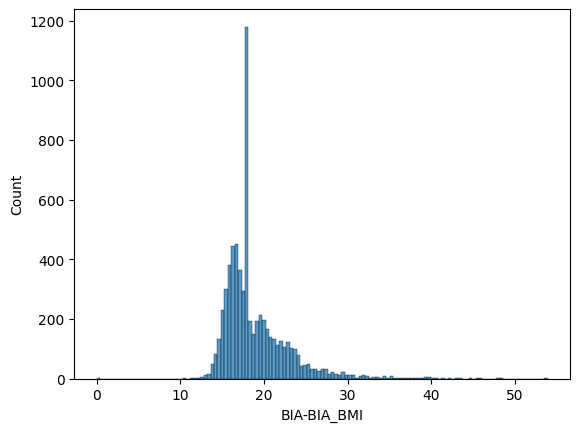

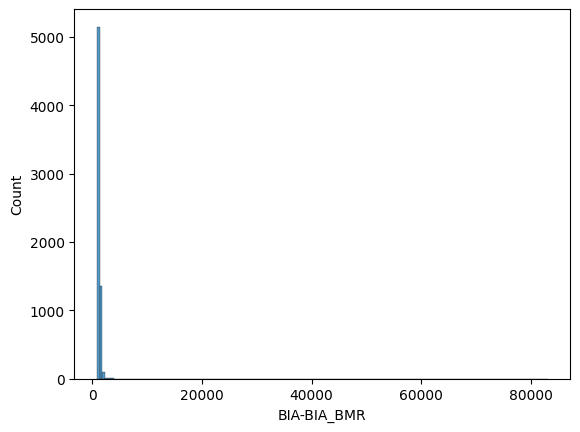

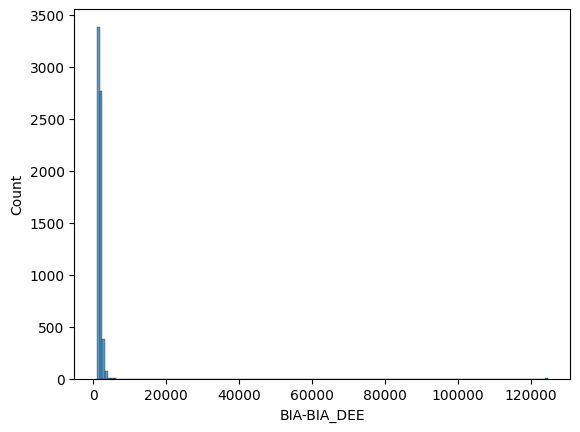

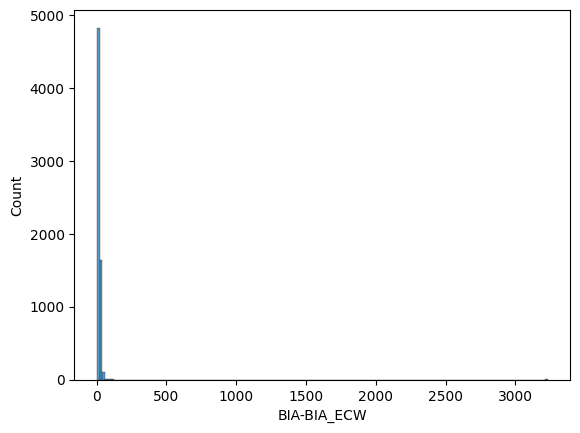

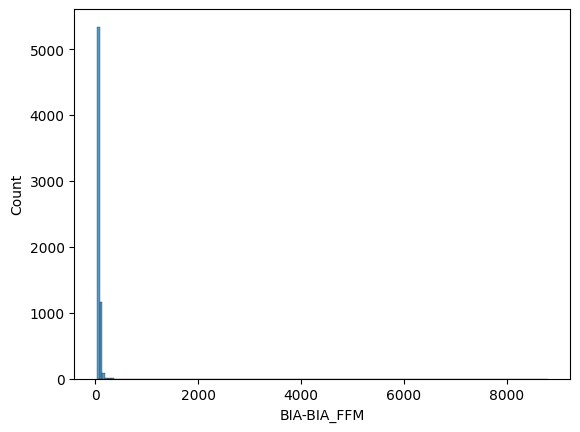

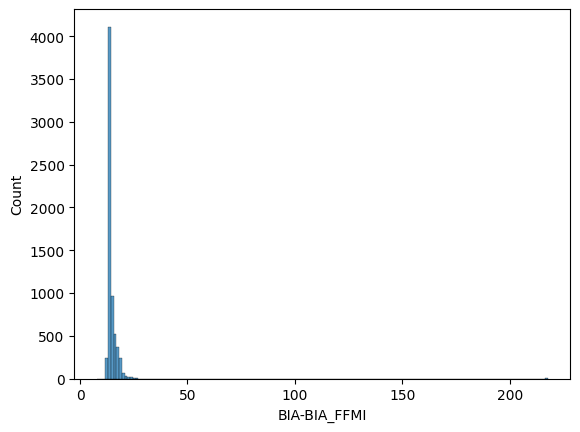

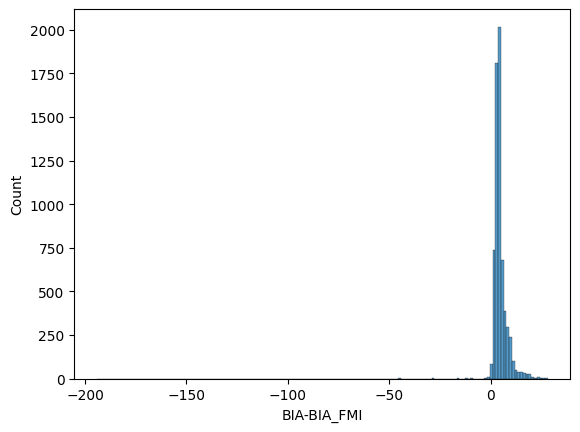

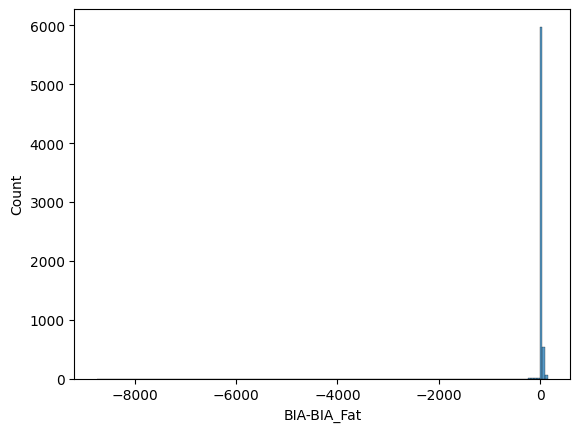

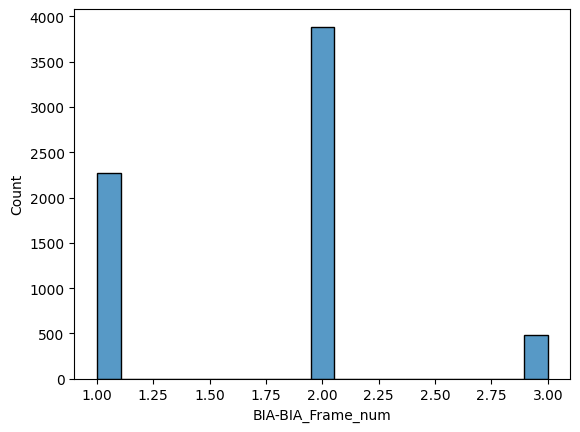

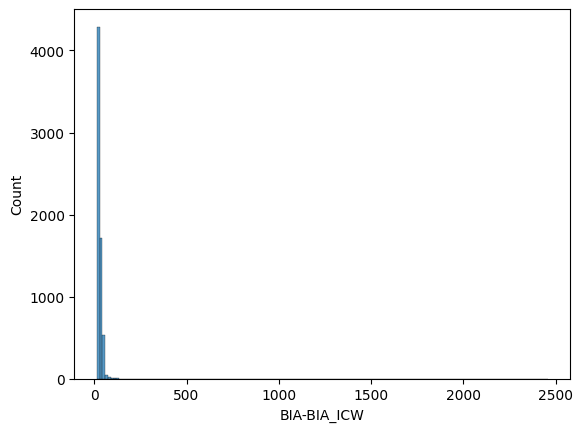

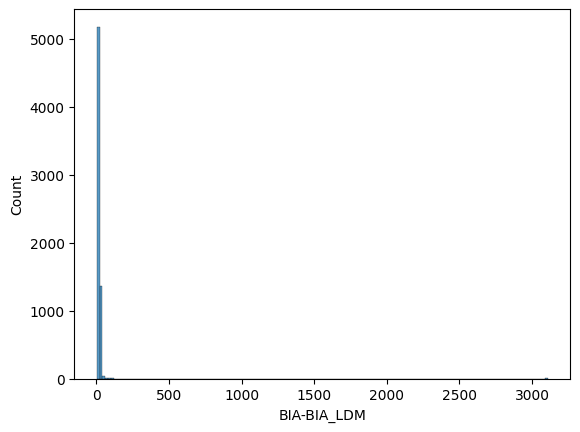

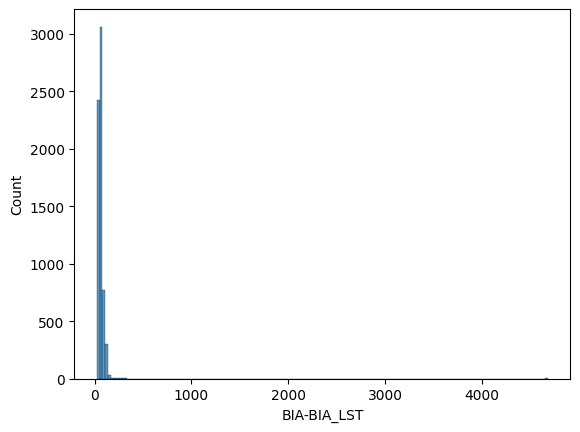

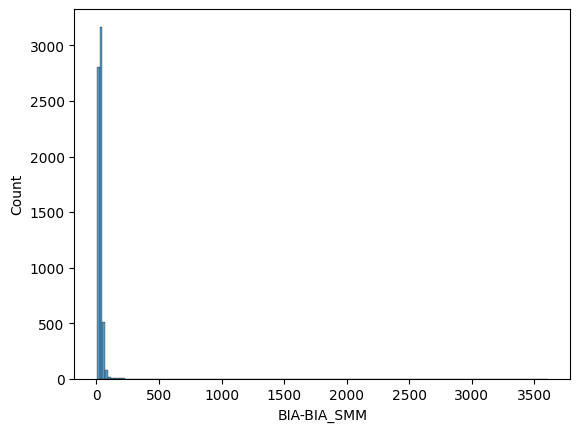

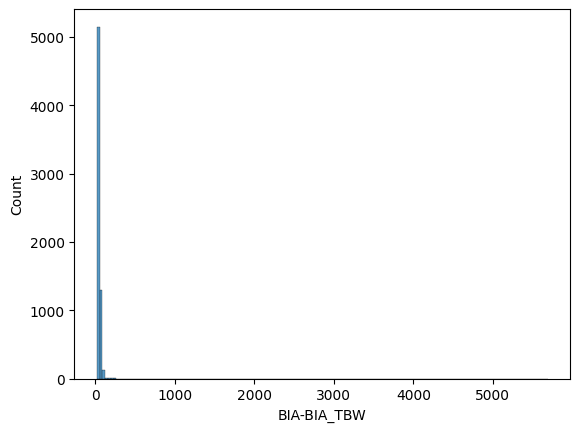

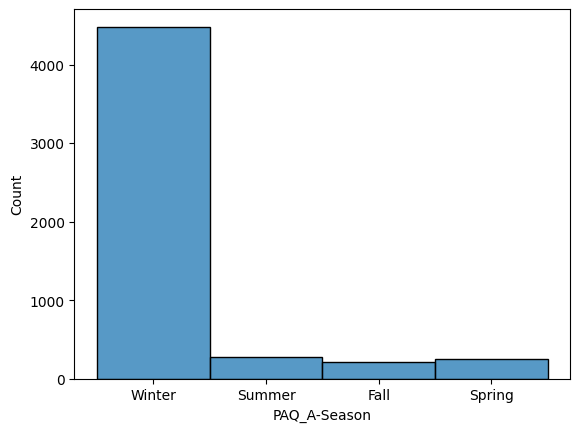

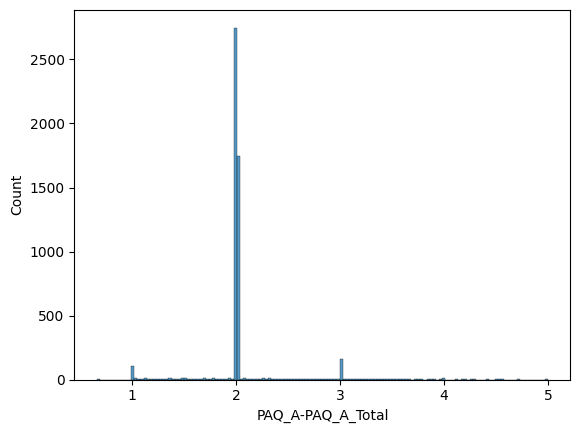

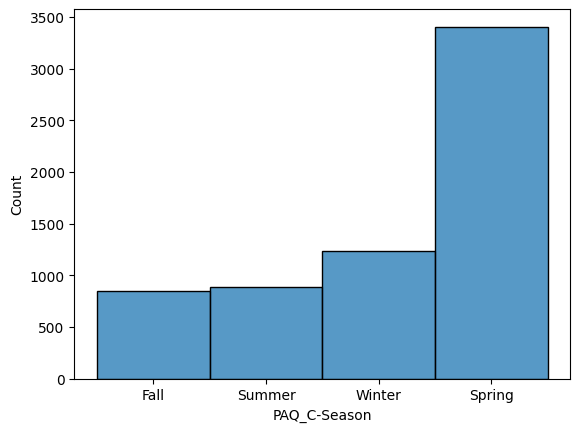

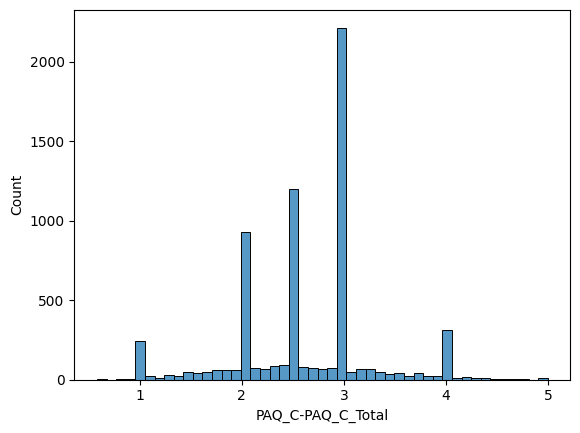

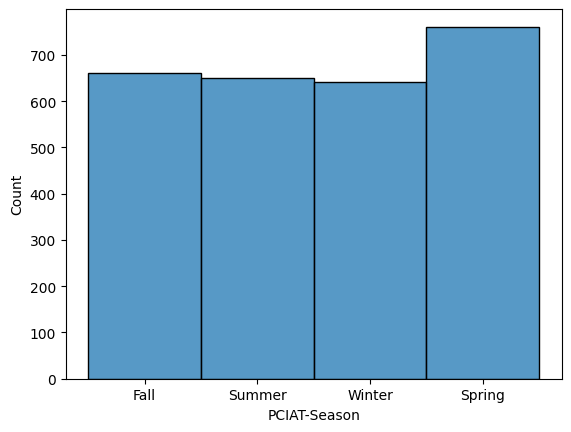

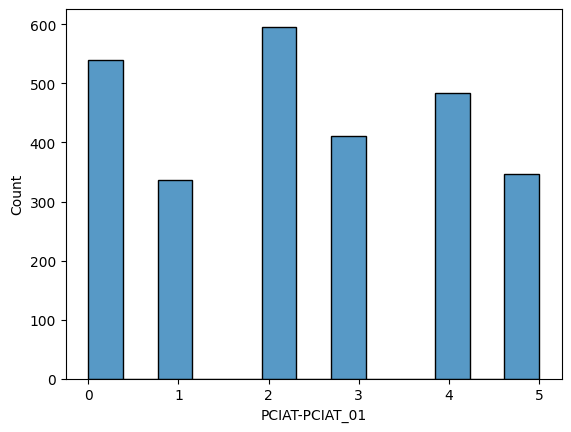

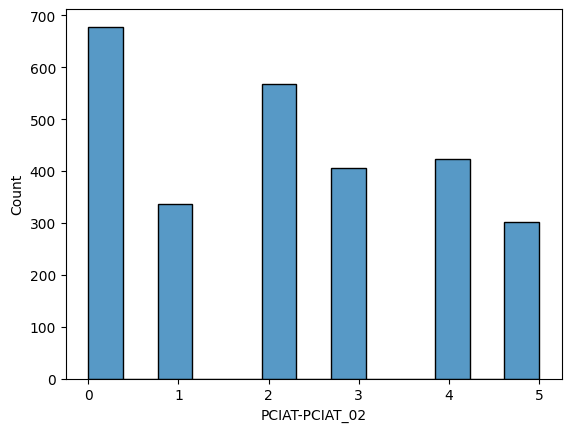

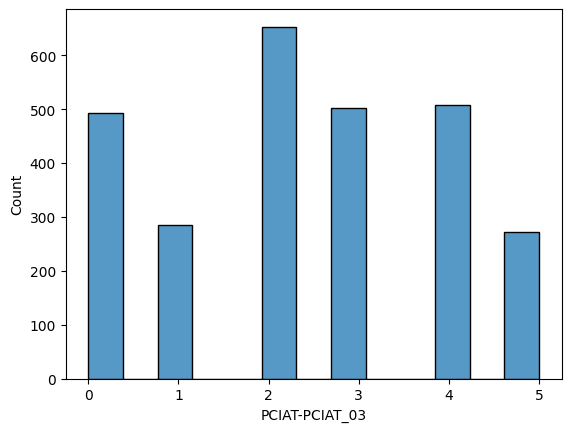

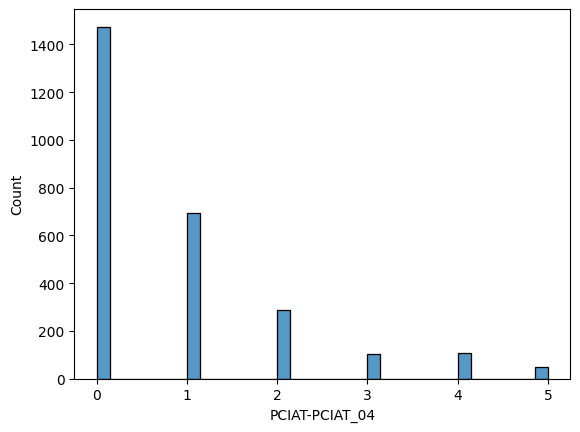

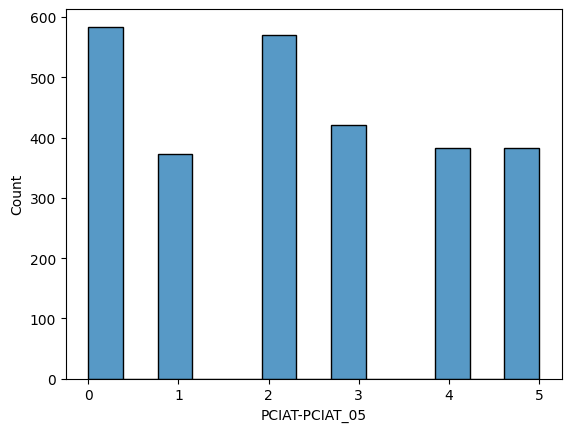

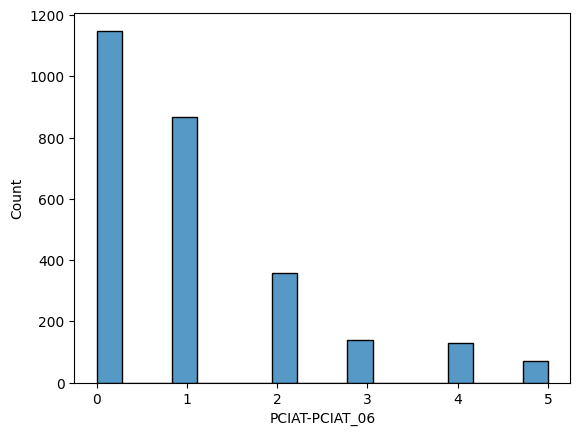

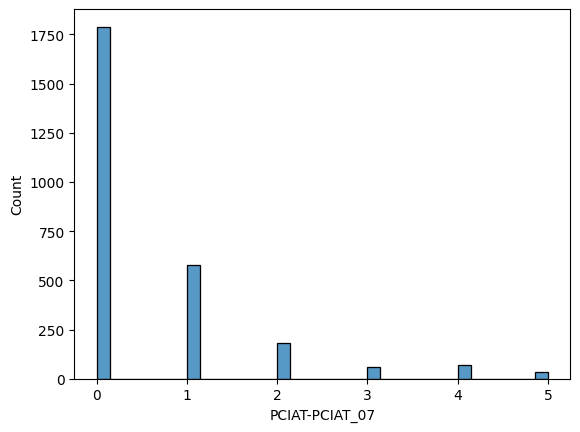

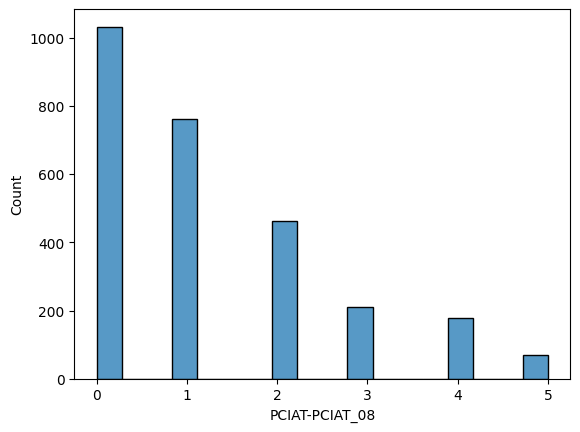

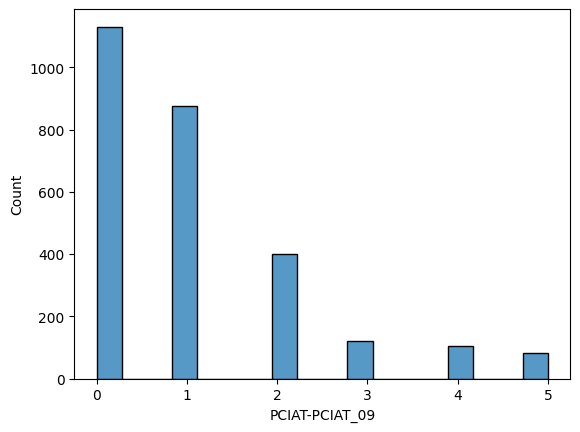

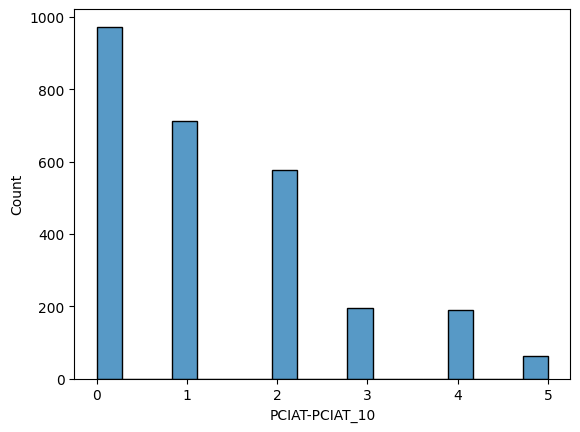

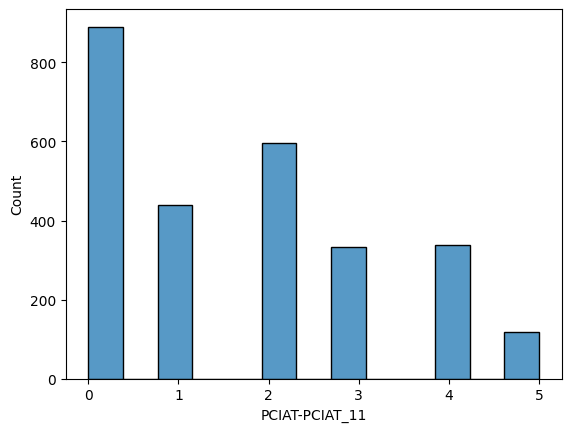

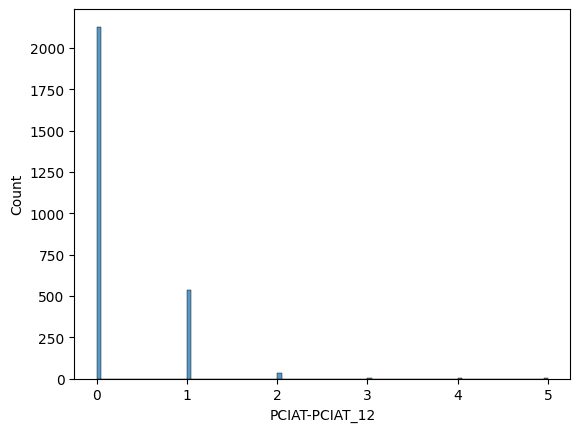

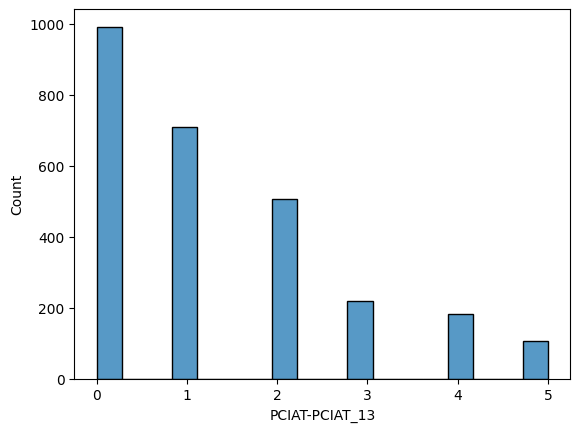

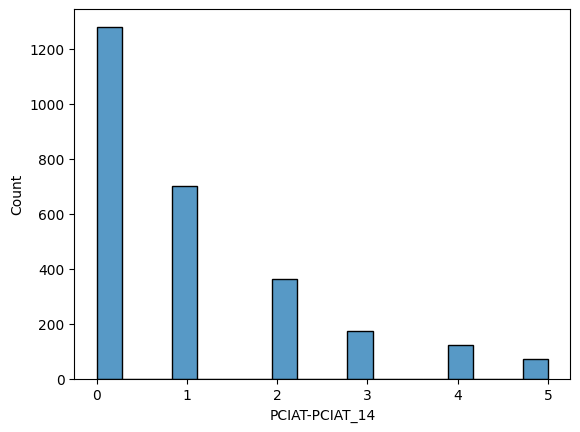

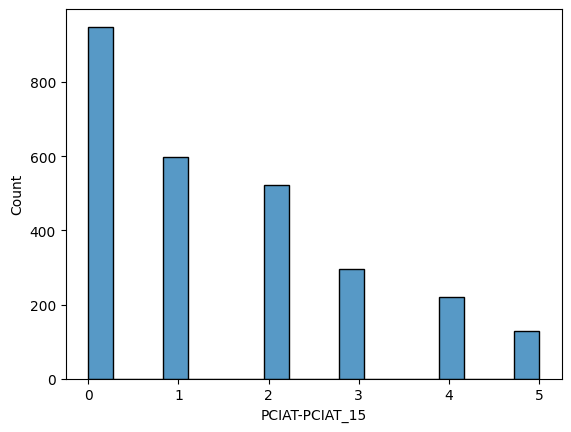

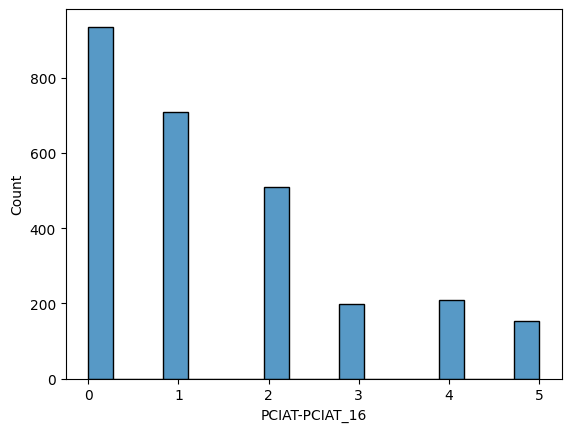

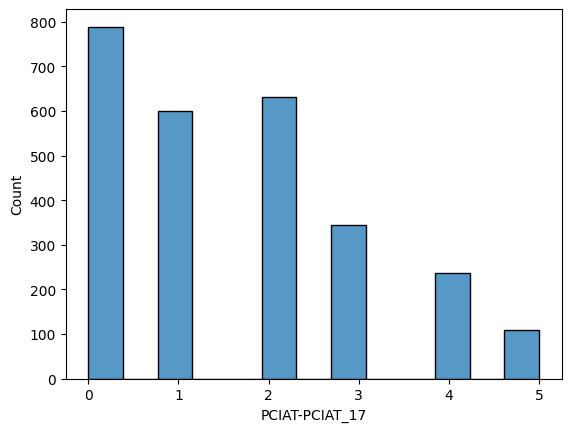

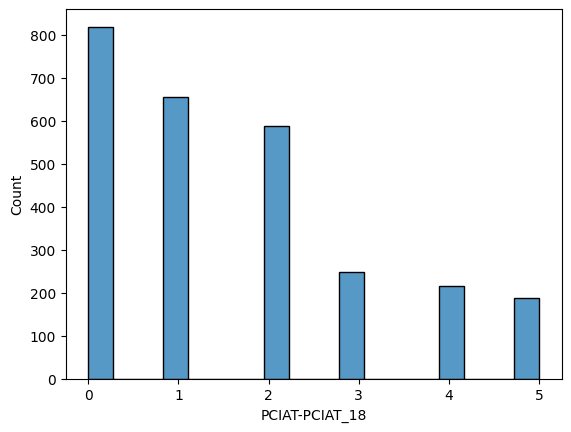

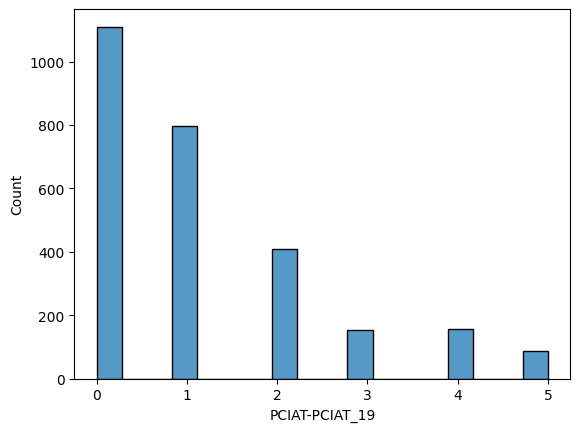

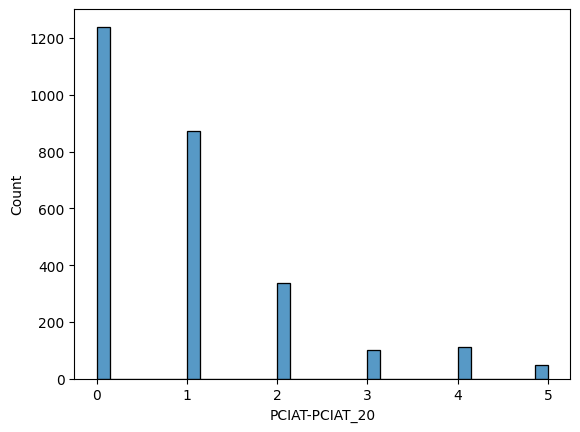

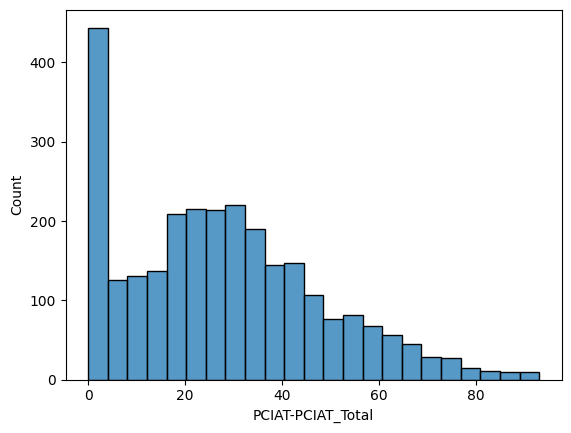

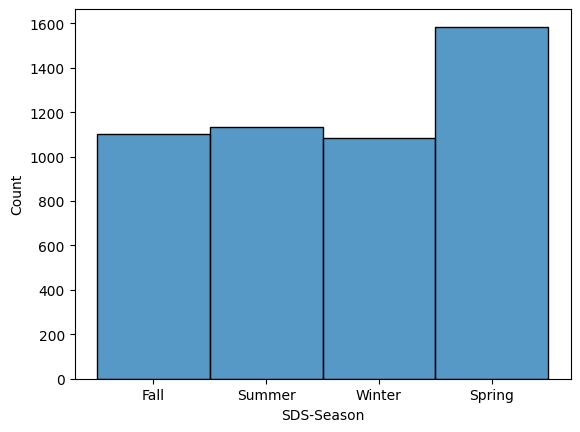

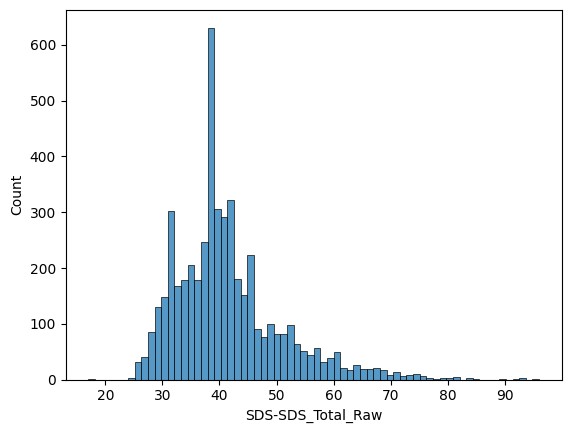

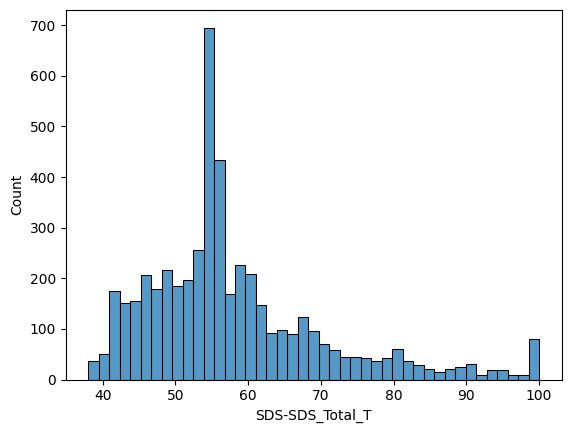

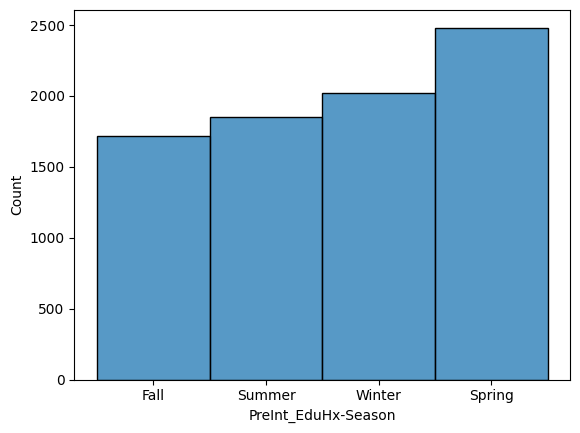

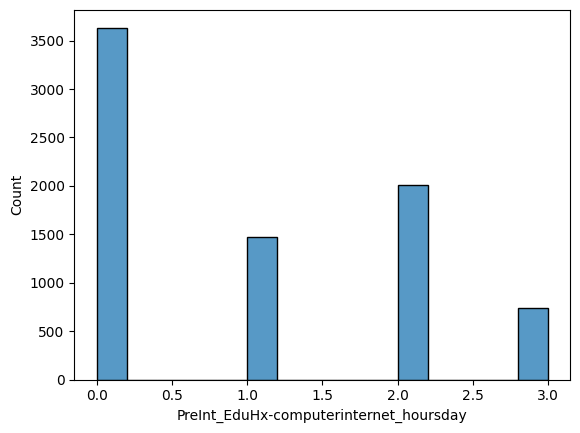

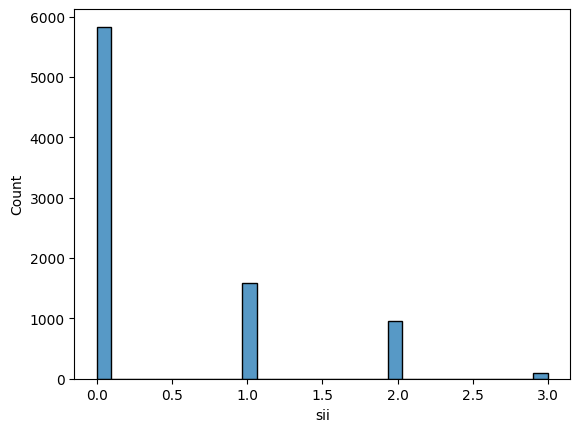

In [8]:
for col in df.columns:
    plt.figure()
    sns.histplot(df[col])
    plt.plot()

## **Outliers Management**

### Physical-Diastolic_BP

<Axes: xlabel='Physical-Diastolic_BP', ylabel='Count'>

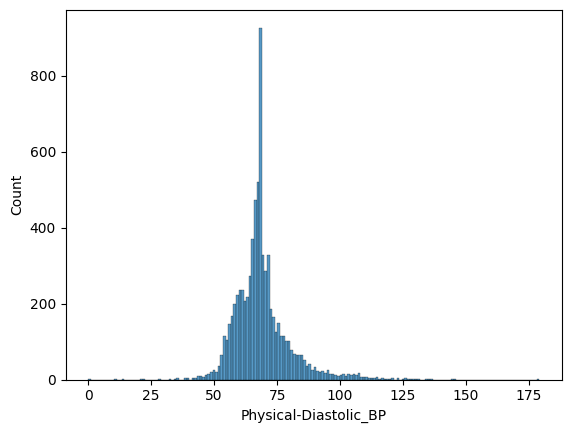

In [17]:
sns.histplot(df["Physical-Diastolic_BP"])

In [25]:
# Rimuovo i valori fisicamente impossibili
print((df["Physical-Diastolic_BP"] < 30).sum()) # Ipotensione severa da ospedale
print((df["Physical-Diastolic_BP"] > 140).sum()) # Ipertensione diastolica severa o crisi ipertensiva, da ospedale
df = df[(df['Physical-Diastolic_BP'] >= 30) & (df['Physical-Diastolic_BP'] <= 140)]

6
4


### Physical-HeartRate

<Axes: xlabel='Physical-HeartRate', ylabel='Count'>

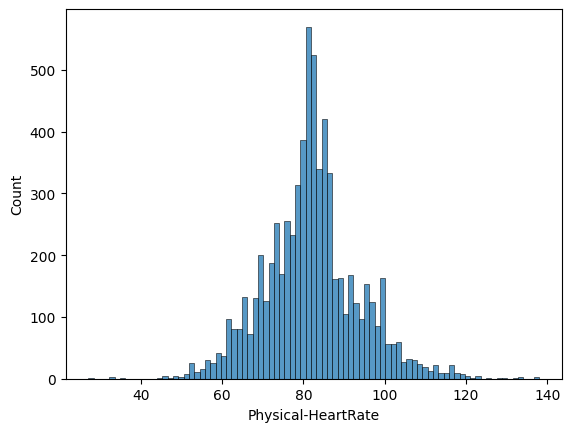

In [ ]:
sns.histplot(df["Physical-HeartRate"])
# Okay così

### Physical-Systolic_BP

<Axes: xlabel='Physical-Systolic_BP', ylabel='Count'>

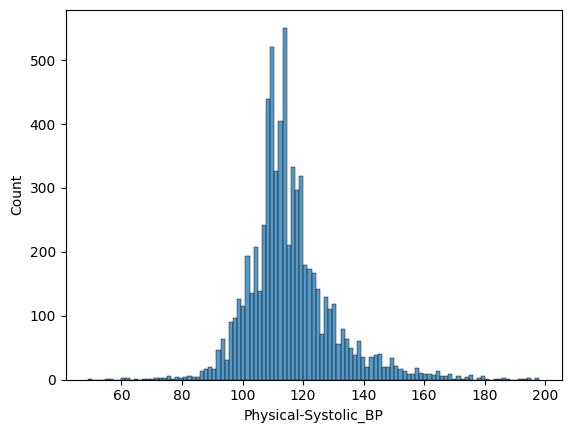

In [29]:
sns.histplot(df["Physical-Systolic_BP"])

In [30]:
# Rimuovo i valori impossibili
df = df[(df['Physical-Systolic_BP'] >= 60) & (df['Physical-Systolic_BP'] <= 220)]

### Fitness_Endurance-Max_Stage

<Axes: xlabel='Fitness_Endurance-Max_Stage', ylabel='Count'>

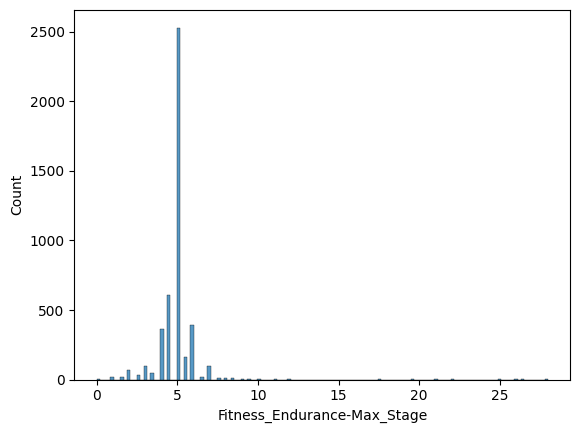

In [31]:
sns.histplot(df["Fitness_Endurance-Max_Stage"])

<Axes: xlabel='Fitness_Endurance-Max_Stage', ylabel='Count'>

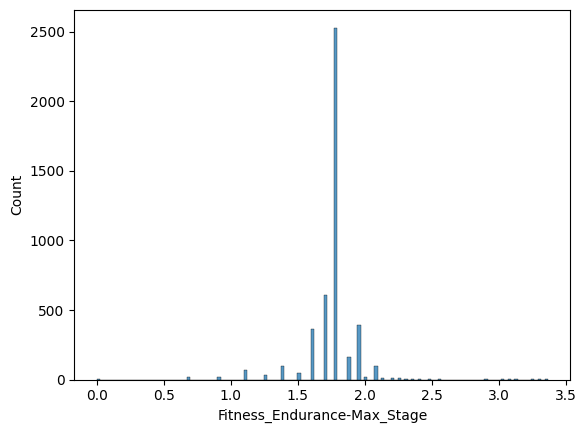

In [32]:
sns.histplot(np.log1p(df["Fitness_Endurance-Max_Stage"]))

Da decidere se usare il log oppure lasciarlo originale, è più centrato ma si perde il vero senso dei valori (comunque non grave)

### Fitness_Endurance-Time_Mins

<Axes: xlabel='Fitness_Endurance-Time_Mins', ylabel='Count'>

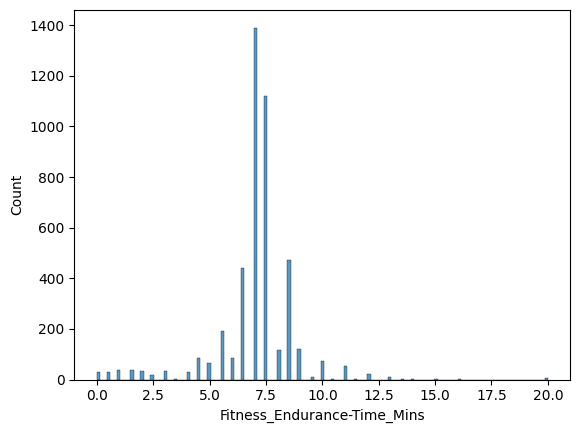

In [33]:
sns.histplot(df["Fitness_Endurance-Time_Mins"])

Si può lasciare così

### Fitness_Endurance-Time_Sec

<Axes: xlabel='Fitness_Endurance-Time_Sec', ylabel='Count'>

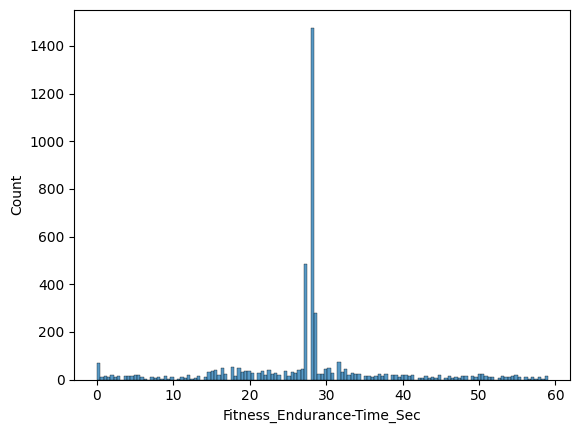

In [36]:
sns.histplot(df["Fitness_Endurance-Time_Sec"])

Va bene così